Using device: cuda
LOADING SAVED TRAINING HISTORY
✅ Training history loaded successfully!
   Saved on: 2026-03-19 08:34:01
   Epochs: 15

TRAINING HISTORY SUMMARY


,Epoch,Model1_Train_Loss,Model1_Train_Acc,Model1_Test_Acc,Model2_Train_Loss,Model2_Train_Acc,Model2_Test_Acc,Model3_Train_Loss,Model3_Train_Acc,Model3_Test_Acc
0,1,0.533180,84.713131,81.380608,0.943692,70.729399,75.944991,0.350684,89.354355,93.419637
1,2,0.377559,89.685268,83.001690,0.716422,78.952262,79.333128,0.180560,95.005857,94.614321
2,3,0.345604,90.664110,81.538107,0.668978,80.509540,79.859404,0.142105,96.236027,94.806392
3,4,0.327486,91.174874,84.676552,0.631095,81.854206,80.977259,0.120069,96.883459,95.305778
4,5,0.315424,91.479480,84.918562,0.603455,82.750816,81.261524,0.104974,97.297431,95.497849
5,6,0.303771,91.837859,84.542102,0.576517,83.582566,82.652120,0.093531,97.568118,95.751383
6,7,0.298016,91.987432,84.918562,0.558122,84.157859,83.539490,0.084731,97.792643,95.778273
7,8,0.290550,92.220229,84.676552,0.543063,84.567860,83.896742,0.077867,97.974811,96.031807
8,9,0.286403,92.319669,85.398740,0.534995,84.804960,83.270590,0.071527,98.110485,96.108636
9,10,0.282099,92.481982,86.516595,0.531480,84.891659,79.763368,0.065913,98.236729,96.135526



FINAL EPOCH RESULTS


,Model,Final Train Loss,Final Train Acc,Final Test Acc
0,Baseline MLP,0.2647,92.97%,86.45%
1,Improved MLP,0.4980,85.91%,84.96%
2,CNN,0.0482,98.65%,96.06%


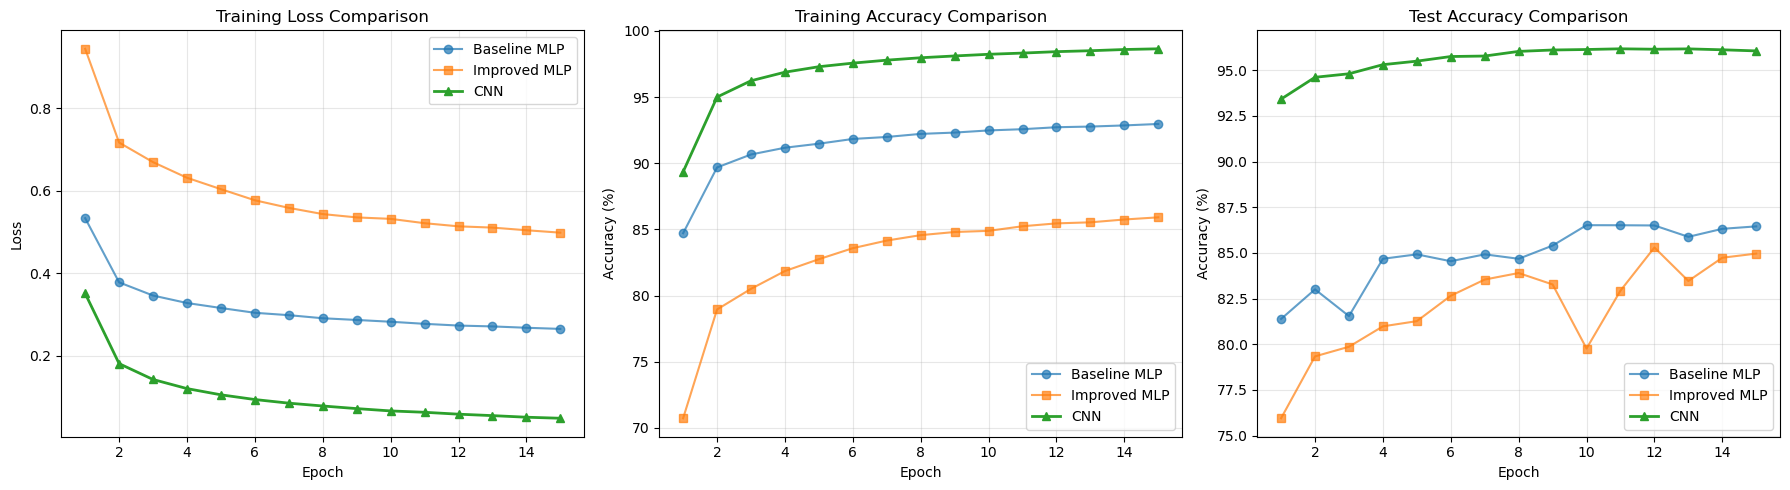


✅ Done! You can now see all training metrics without retraining.


In [2]:
# ==================== Simple Demo to Load Saved Models and Training History ====================
# Run this in a new ipynb file

import torch
import torch.nn as nn
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ==================== Setup ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

SAVE_DIR = Path('saved_models')
if not SAVE_DIR.exists():
    raise Exception("❌ saved_models folder not found!")

# ==================== Redefine Model Architectures (Must match training) ====================
class BaselineMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(32*32*3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

class ImprovedMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(32*32*3, 1024),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# ==================== Load Training History ====================
def load_training_history():
    history_path = SAVE_DIR / 'training_history.pkl'
    if history_path.exists():
        with open(history_path, 'rb') as f:
            history = pickle.load(f)
        print(f"✅ Training history loaded successfully!")
        print(f"   Saved on: {history['metadata']['saved_date']}")
        print(f"   Epochs: {history['metadata']['epochs']}")
        return history
    else:
        print("❌ Training history file not found")
        return None

# ==================== Display Training History ====================
def display_training_history(history):
    """Display the saved training metrics"""
    if history is None:
        return
    
    print("\n" + "="*60)
    print("TRAINING HISTORY SUMMARY")
    print("="*60)
    
    # Create DataFrame from history
    data = {
        'Epoch': list(range(1, history['metadata']['epochs'] + 1)),
        'Model1_Train_Loss': history['model1']['train_loss'],
        'Model1_Train_Acc': history['model1']['train_acc'],
        'Model1_Test_Acc': history['model1']['test_acc'],
        'Model2_Train_Loss': history['model2']['train_loss'],
        'Model2_Train_Acc': history['model2']['train_acc'],
        'Model2_Test_Acc': history['model2']['test_acc'],
        'Model3_Train_Loss': history['model3']['train_loss'],
        'Model3_Train_Acc': history['model3']['train_acc'],
        'Model3_Test_Acc': history['model3']['test_acc'],
    }
    
    df = pd.DataFrame(data)
    display(df)
    
    # Final epoch summary
    print("\n" + "="*60)
    print("FINAL EPOCH RESULTS")
    print("="*60)
    
    final_results = pd.DataFrame({
        'Model': ['Baseline MLP', 'Improved MLP', 'CNN'],
        'Final Train Loss': [
            f"{history['model1']['train_loss'][-1]:.4f}",
            f"{history['model2']['train_loss'][-1]:.4f}",
            f"{history['model3']['train_loss'][-1]:.4f}"
        ],
        'Final Train Acc': [
            f"{history['model1']['train_acc'][-1]:.2f}%",
            f"{history['model2']['train_acc'][-1]:.2f}%",
            f"{history['model3']['train_acc'][-1]:.2f}%"
        ],
        'Final Test Acc': [
            f"{history['model1']['test_acc'][-1]:.2f}%",
            f"{history['model2']['test_acc'][-1]:.2f}%",
            f"{history['model3']['test_acc'][-1]:.2f}%"
        ]
    })
    
    display(final_results)

# ==================== Visualize Training History ====================
def plot_training_history(history):
    """Plot training curves"""
    if history is None:
        return
    
    m1 = history['model1']
    m2 = history['model2']
    m3 = history['model3']
    epochs = history['metadata']['epochs']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Training Loss
    ax = axes[0]
    ax.plot(range(1, epochs+1), m1['train_loss'], 'o-', label='Baseline MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m2['train_loss'], 's-', label='Improved MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m3['train_loss'], '^-', label='CNN', linewidth=2)
    ax.set_title('Training Loss Comparison')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Training Accuracy
    ax = axes[1]
    ax.plot(range(1, epochs+1), m1['train_acc'], 'o-', label='Baseline MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m2['train_acc'], 's-', label='Improved MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m3['train_acc'], '^-', label='CNN', linewidth=2)
    ax.set_title('Training Accuracy Comparison')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Test Accuracy
    ax = axes[2]
    ax.plot(range(1, epochs+1), m1['test_acc'], 'o-', label='Baseline MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m2['test_acc'], 's-', label='Improved MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m3['test_acc'], '^-', label='CNN', linewidth=2)
    ax.set_title('Test Accuracy Comparison')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==================== Main ====================
def main():
    print("="*60)
    print("LOADING SAVED TRAINING HISTORY")
    print("="*60)
    
    # Load history
    history = load_training_history()
    
    if history:
        # Display numerical data
        display_training_history(history)
        
        # Plot curves
        plot_training_history(history)
        
        print("\n✅ Done! You can now see all training metrics without retraining.")
    else:
        print("\n❌ No training history found. Please train the models first.")

# Run
if __name__ == "__main__":
    main()